# Matplotlib y Seaborn — Guía Práctica de Visualización

## ¿Por qué visualizar datos?

Imagina que tienes 1 000 números. ¿Cuánto tiempo necesitarías para entender si hay una tendencia?
Una buena gráfica puede revelar en segundos lo que tardarías horas en descubrir leyendo tablas.

La visualización es útil para:
- **Explorar** un dataset antes de analizarlo
- **Detectar** errores, datos atípicos y patrones
- **Comunicar** resultados a otras personas de forma clara
- **Verificar** los supuestos de un modelo estadístico

## ¿Matplotlib o Seaborn?

| Característica | Matplotlib | Seaborn |
|---|---|---|
| Nivel | Bajo nivel (mucho control) | Alto nivel (menos código) |
| Tipos de gráficas | Todos | Especializadas en estadística |
| Integración con pandas | Manual | Directa (`data=df`) |
| Curva de aprendizaje | Más lenta | Más rápida |

**Recomendación:** Aprende Matplotlib primero para entender cómo funciona, luego usa Seaborn cuando quieras hacer
gráficas estadísticas rápidamente. Seaborn *está construida sobre* Matplotlib, así que puedes combinarlas.

## Anatomía de una figura

```
Figure  ← el lienzo completo (toda la imagen)
  └── Axes  ← un gráfico individual dentro del lienzo
        ├── Title      (título)
        ├── x-axis     (eje horizontal con etiquetas)
        ├── y-axis     (eje vertical con etiquetas)
        ├── Legend     (leyenda)
        └── Plot       (líneas, barras, puntos, etc.)
```

Una Figure puede contener **varios Axes** (subplots). Eso es lo que usamos cuando queremos poner
varias gráficas una al lado de la otra.

## Dos formas de usar Matplotlib

```python
# Forma 1: Interfaz funcional (rápida, para gráficas simples)
plt.plot([1, 2, 3], [4, 5, 6])
plt.title('Mi gráfica')
plt.show()

# Forma 2: Interfaz orientada a objetos (recomendada, control total)
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title('Mi gráfica')
plt.show()
```

Usaremos casi siempre la **Forma 2** porque es más clara cuando hay múltiples subplots.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configuración global: afecta todas las gráficas del notebook
plt.rcParams['figure.figsize'] = (10, 4)   # tamaño por defecto
plt.rcParams['axes.grid'] = True            # cuadrícula activada
plt.rcParams['grid.alpha'] = 0.3            # cuadrícula semitransparente
plt.rcParams['font.size'] = 11              # tamaño de texto
sns.set_theme(style='whitegrid')            # estilo general de Seaborn

rng = np.random.default_rng(42)             # generador de números aleatorios reproducible
print('Librerías listas.')

Librerías listas.


---
## 1. Gráfica de Línea (`ax.plot`)

### ¿Cuándo usar una gráfica de línea?

Úsala cuando el **orden importa**: cuando los puntos en el eje X son continuos o tienen una secuencia
lógica (tiempo, pasos, posición). Es la gráfica más común para:
- Series de tiempo (temperatura, ventas, precios a lo largo del tiempo)
- Funciones matemáticas
- Seguimiento de una variable a través de categorías ordenadas

**¿Cuándo NO usarla?** Cuando el eje X son categorías sin orden (como nombre de países, materias, etc.).
En ese caso, una gráfica de barras es más apropiada.

### Ejemplo 1 — Funciones matemáticas

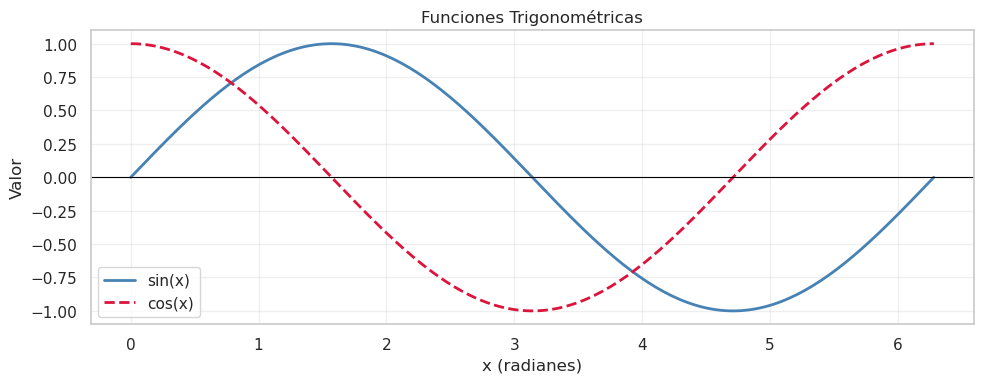

In [14]:
# Generamos 200 puntos entre 0 y 2π
x = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots()

ax.plot(x, np.sin(x), label='sin(x)', color='steelblue', linewidth=2)
ax.plot(x, np.cos(x), label='cos(x)', color='crimson',   linewidth=2, linestyle='--')

ax.set_title('Funciones Trigonométricas')
ax.set_xlabel('x (radianes)')
ax.set_ylabel('Valor')
ax.legend()               # muestra la leyenda con los 'label' de cada plot
ax.axhline(0, color='black', linewidth=0.8)  # línea horizontal en y=0

plt.tight_layout()        # ajusta los márgenes automáticamente
plt.show()

### Ejemplo 2 — Múltiples series con un ciclo `for`

Cuando tenemos **muchas series** (varios años, varias ciudades, varios experimentos), sería repetitivo
escribir `ax.plot(...)` una vez por cada serie. Un ciclo `for` resuelve esto elegantemente.

Imagina que tienes datos de temperatura mensual para 3 ciudades de Guatemala:

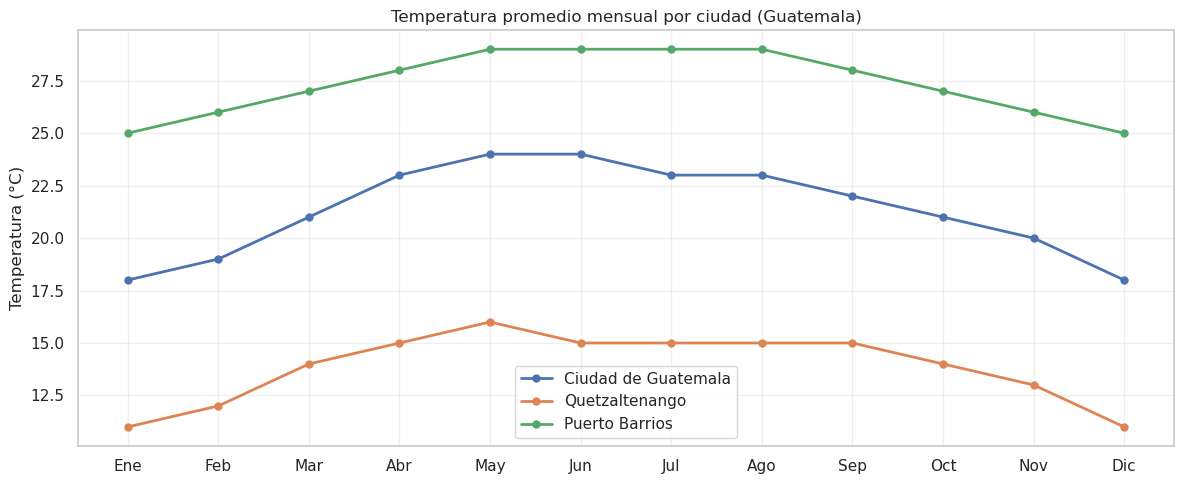

Ciudad de Guatemala       promedio anual: 21.3 °C
Quetzaltenango            promedio anual: 13.8 °C
Puerto Barrios            promedio anual: 27.3 °C


In [15]:
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Datos de temperatura promedio mensual (°C) para 3 ciudades
# Cada clave es el nombre de la ciudad, el valor es la lista de 12 temperaturas
temperaturas_ciudades = {
    'Ciudad de Guatemala': [18, 19, 21, 23, 24, 24, 23, 23, 22, 21, 20, 18],
    'Quetzaltenango':      [11, 12, 14, 15, 16, 15, 15, 15, 15, 14, 13, 11],
    'Puerto Barrios':      [25, 26, 27, 28, 29, 29, 29, 29, 28, 27, 26, 25],
}

x = range(12)   # posiciones en el eje X: 0, 1, 2, ..., 11

fig, ax = plt.subplots(figsize=(12, 5))

# === Ciclo for: graficamos cada ciudad sin repetir código ===
# Si mañana agregas una cuarta ciudad al diccionario, la gráfica la incluye automáticamente.
for ciudad, temps in temperaturas_ciudades.items():
    ax.plot(x, temps,
            marker='o',        # punto en cada mes
            linewidth=2,
            markersize=5,
            label=ciudad)      # la leyenda usará el nombre de la ciudad

ax.set_xticks(x)
ax.set_xticklabels(meses)
ax.set_title('Temperatura promedio mensual por ciudad (Guatemala)')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()

# ¿Cuál es la ciudad más caliente en promedio?
for ciudad, temps in temperaturas_ciudades.items():
    promedio = sum(temps) / len(temps)   # promedio manual con for implícito
    print(f'{ciudad:<25} promedio anual: {promedio:.1f} °C')

---
## 2. Gráfica de Dispersión — Scatter (`ax.scatter`)

### ¿Cuándo usar scatter?

Cuando quieres ver la **relación entre dos variables numéricas**. Cada punto representa
una observación con su valor en X e Y.

Casos de uso típicos:
- ¿Estudiar más horas se relaciona con mejores notas?
- ¿Hay correlación entre el ingreso familiar y el rendimiento académico?
- Detección de puntos atípicos (outliers)
- Visualización de clusters antes de aplicar algoritmos de clustering

**Patrón de lectura:**
- Puntos en diagonal ascendente → correlación positiva (ambas variables suben juntas)
- Puntos en diagonal descendente → correlación negativa
- Nube de puntos sin patrón → sin correlación

### Ejemplo 1 — Horas de estudio vs. Nota

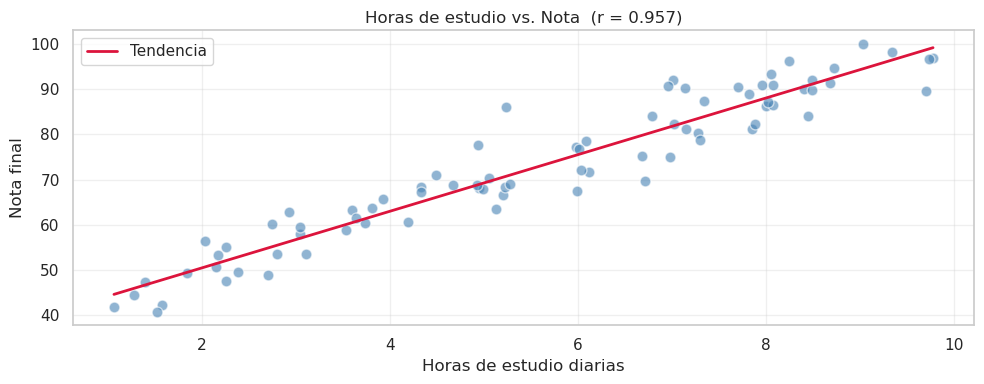

Correlación de Pearson r = 0.957
Interpretación:
  Correlación FUERTE


In [16]:
# Simulamos datos de 80 estudiantes
n = 80
horas = rng.uniform(1, 10, n)
notas = (40 + 6 * horas + rng.normal(0, 5, n)).clip(40, 100)  # relación lineal + ruido

fig, ax = plt.subplots()

ax.scatter(horas, notas,
           alpha=0.6,             # transparencia (útil cuando hay puntos superpuestos)
           color='steelblue',
           edgecolors='white',    # borde blanco en cada punto para mejor legibilidad
           s=60)                  # tamaño de los puntos

# Línea de tendencia usando ajuste de polinomio de grado 1 (recta)
coefs  = np.polyfit(horas, notas, 1)   # calcula m (pendiente) y b (intercepto) de y = mx + b
recta  = np.poly1d(coefs)               # crea la función de la recta
x_line = np.linspace(horas.min(), horas.max(), 100)
ax.plot(x_line, recta(x_line), color='crimson', linewidth=2, label='Tendencia')

# Correlación de Pearson: mide qué tan lineal es la relación (-1 a 1)
r = np.corrcoef(horas, notas)[0, 1]

ax.set_title(f'Horas de estudio vs. Nota  (r = {r:.3f})')
ax.set_xlabel('Horas de estudio diarias')
ax.set_ylabel('Nota final')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Correlación de Pearson r = {r:.3f}')
print('Interpretación:')
if abs(r) > 0.7:
    print('  Correlación FUERTE')
elif abs(r) > 0.4:
    print('  Correlación MODERADA')
else:
    print('  Correlación DÉBIL')

### Ejemplo 2 — Colorear puntos por categoría con `for`

Un truco muy útil: colorear cada punto según a qué grupo pertenece.
Podemos hacerlo con un ciclo `for` que itera sobre los grupos y filtra los datos.

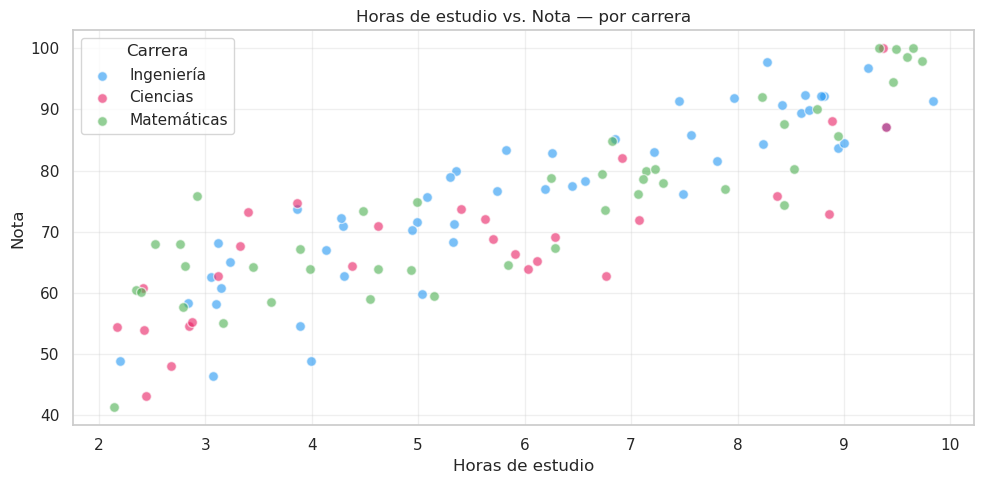

Promedio de nota por carrera:
  Ingeniería    : 76.3
  Ciencias      : 68.0
  Matemáticas   : 74.8


In [17]:
# Dataset con 3 carreras
n_total = 120
carreras = rng.choice(['Ingeniería', 'Ciencias', 'Matemáticas'], n_total)
horas_c  = rng.uniform(2, 10, n_total)
notas_c  = (45 + 5 * horas_c + rng.normal(0, 7, n_total)).clip(40, 100)

df_est = pd.DataFrame({'carrera': carreras, 'horas': horas_c, 'nota': notas_c})

# Definimos un color para cada carrera
colores_carrera = {
    'Ingeniería':  '#2196F3',   # azul
    'Ciencias':    '#E91E63',   # rosa
    'Matemáticas': '#4CAF50',   # verde
}

fig, ax = plt.subplots(figsize=(10, 5))

# === Ciclo for: graficamos un scatter por cada carrera ===
# Esto nos permite dar a cada grupo su propio color y etiqueta en la leyenda
for carrera, color in colores_carrera.items():
    # Filtrar solo los estudiantes de esta carrera
    mask = df_est['carrera'] == carrera
    datos_carrera = df_est[mask]

    ax.scatter(
        datos_carrera['horas'],
        datos_carrera['nota'],
        color=color,
        alpha=0.6,
        s=50,
        edgecolors='white',
        label=carrera           # cada carrera aparece por separado en la leyenda
    )

ax.set_title('Horas de estudio vs. Nota — por carrera')
ax.set_xlabel('Horas de estudio')
ax.set_ylabel('Nota')
ax.legend(title='Carrera')
plt.tight_layout()
plt.show()

# Resumen estadístico por carrera usando un ciclo for
print('Promedio de nota por carrera:')
for carrera in colores_carrera:
    notas_carrera = df_est.loc[df_est['carrera'] == carrera, 'nota']
    print(f'  {carrera:<14}: {notas_carrera.mean():.1f}')

---
## 3. Gráfica de Barras (`ax.bar` / `ax.barh`)

### ¿Cuándo usar barras?

Cuando quieres **comparar valores entre categorías**. Las categorías NO tienen orden natural
(o si lo tienen, no es lo más importante).

Ejemplos de uso:
- Ventas por producto
- Número de estudiantes por carrera
- Promedio de notas por materia
- Comparar dos grupos en varias categorías (barras agrupadas)

**Barras verticales vs horizontales:**
- Verticales: cuando las etiquetas son cortas y hay pocas categorías
- Horizontales: cuando las etiquetas son largas o hay muchas categorías

### Ejemplo 1 — Barras con colores condicionales y etiquetas automáticas

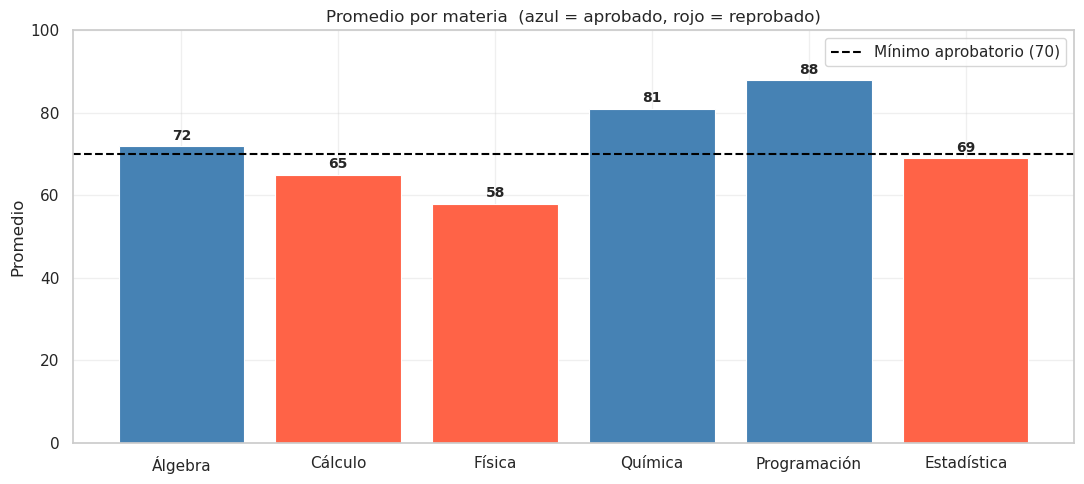

Materias aprobadas: 3 / Reprobadas: 3


In [18]:
materias   = ['Álgebra', 'Cálculo', 'Física', 'Química', 'Programación', 'Estadística']
promedios  = [72, 65, 58, 81, 88, 69]
MINIMO_APROBATORIO = 70

# === Condicional dentro de ciclo for ===
# Determinamos el color de cada barra según si el promedio aprueba o no
colores = []
for promedio in promedios:
    if promedio >= MINIMO_APROBATORIO:
        colores.append('steelblue')    # aprobado → azul
    else:
        colores.append('tomato')       # reprobado → rojo

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(materias, promedios, color=colores, edgecolor='white', linewidth=0.8)

# === Segundo ciclo for: agregar etiqueta con el valor sobre cada barra ===
for bar in bars:
    valor = bar.get_height()          # altura de la barra = valor del promedio
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x: centro horizontal de la barra
        valor + 0.8,                         # y: justo encima de la barra
        str(int(valor)),                     # texto: el valor como entero
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Línea de referencia para el mínimo aprobatorio
ax.axhline(MINIMO_APROBATORIO, color='black', linestyle='--', linewidth=1.5,
           label=f'Mínimo aprobatorio ({MINIMO_APROBATORIO})')

ax.set_title('Promedio por materia  (azul = aprobado, rojo = reprobado)')
ax.set_ylabel('Promedio')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

# Contar aprobadas y reprobadas
aprobadas  = sum(1 for p in promedios if p >= MINIMO_APROBATORIO)
reprobadas = len(promedios) - aprobadas
print(f'Materias aprobadas: {aprobadas} / Reprobadas: {reprobadas}')

### Ejemplo 2 — Barras agrupadas construidas con `for`

Las barras agrupadas son perfectas para comparar **dos grupos** en las mismas categorías
(por ejemplo: año 2022 vs 2023, hombres vs mujeres, turno matutino vs vespertino).

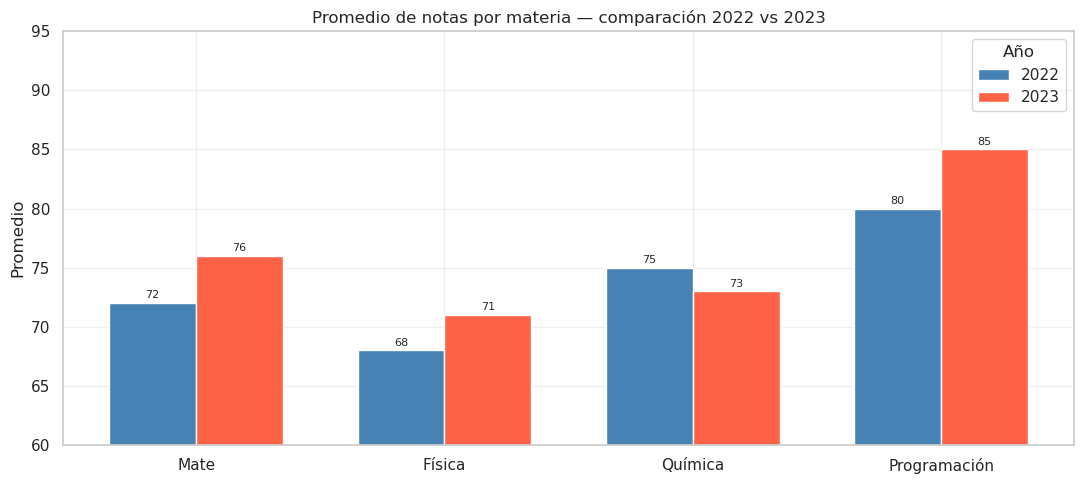

In [19]:
materias_cmp = ['Mate', 'Física', 'Química', 'Programación']

# Promedios por año
grupos = {
    '2022': [72, 68, 75, 80],
    '2023': [76, 71, 73, 85],
}
colores_grupo = {'2022': 'steelblue', '2023': 'tomato'}

x      = np.arange(len(materias_cmp))  # posiciones base: 0, 1, 2, 3
ancho  = 0.35                           # ancho de cada barra
n_grp  = len(grupos)                    # número de grupos

fig, ax = plt.subplots(figsize=(11, 5))

# === Ciclo for sobre los grupos ===
# Calculamos el desplazamiento de cada grupo para que queden lado a lado
for i, (año, promedios_año) in enumerate(grupos.items()):
    # El desplazamiento centra las barras alrededor de cada posición x
    desplazamiento = (i - (n_grp - 1) / 2) * ancho
    bars_g = ax.bar(
        x + desplazamiento,
        promedios_año,
        ancho,
        label=año,
        color=colores_grupo[año],
        edgecolor='white'
    )
    # Agregar etiquetas sobre cada barra
    for bar in bars_g:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                str(int(bar.get_height())),
                ha='center', fontsize=8)

ax.set_title('Promedio de notas por materia — comparación 2022 vs 2023')
ax.set_ylabel('Promedio')
ax.set_xticks(x)
ax.set_xticklabels(materias_cmp)
ax.set_ylim(60, 95)
ax.legend(title='Año')
plt.tight_layout()
plt.show()

---
## 4. Histograma (`ax.hist`)

### ¿Cuándo usar un histograma?

Cuando quieres ver la **distribución de una variable numérica continua**: dónde se concentran
los valores, si hay una forma de campana, si está sesgada hacia un lado, etc.

Diferencia clave con barras: en un histograma el eje X es **continuo** (los valores tienen orden
y significado numérico). Las barras están pegadas porque representan intervalos consecutivos.

**El parámetro `bins`** controla cuántos intervalos se usan:
- Pocos bins → gráfica suavizada, puede ocultar detalles
- Muchos bins → gráfica detallada, puede ser ruidosa
- Un buen punto de partida: `bins = 20` para ~200 datos

### Ejemplo — Comparar distribuciones con ciclo `for`

Grupo A (sin tutoría      | Media=64.4 | Mediana=64.3 | Distribución: aproximadamente simétrica
Grupo B (con tutoría      | Media=74.9 | Mediana=75.1 | Distribución: aproximadamente simétrica
Grupo C (intensivo)       | Media=81.7 | Mediana=82.2 | Distribución: aproximadamente simétrica


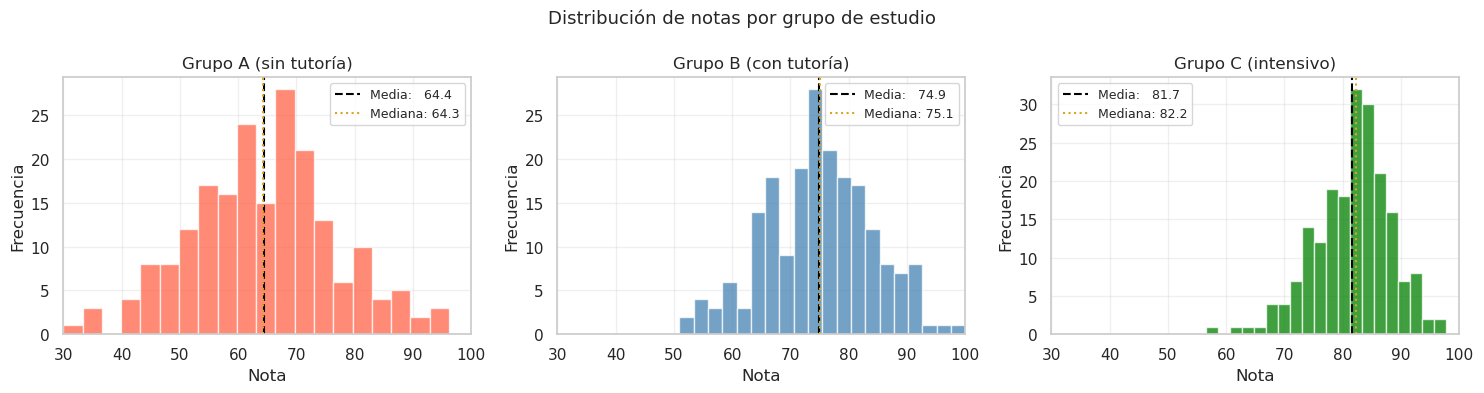

In [20]:
# Notas de tres grupos diferentes
grupos_notas = {
    'Grupo A (sin tutoría)':  rng.normal(loc=65, scale=12, size=200).clip(30, 100),
    'Grupo B (con tutoría)':  rng.normal(loc=75, scale=9,  size=200).clip(30, 100),
    'Grupo C (intensivo)':    rng.normal(loc=82, scale=7,  size=200).clip(30, 100),
}
colores_hist = ['tomato', 'steelblue', 'green']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# === Ciclo for: histograma para cada grupo ===
for i, (nombre, notas_g) in enumerate(grupos_notas.items()):
    axes[i].hist(notas_g, bins=20,
                 color=colores_hist[i],
                 alpha=0.75,
                 edgecolor='white')

    # Líneas de media y mediana
    media   = notas_g.mean()
    mediana = np.median(notas_g)
    axes[i].axvline(media,   color='black',    linestyle='--', linewidth=1.5,
                    label=f'Media:   {media:.1f}')
    axes[i].axvline(mediana, color='goldenrod', linestyle=':',  linewidth=1.5,
                    label=f'Mediana: {mediana:.1f}')

    axes[i].set_title(nombre)
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlim(30, 100)
    axes[i].legend(fontsize=9)

    # Condicional: mostrar si la distribución está sesgada
    sesgo = (media - mediana)
    if sesgo > 2:
        direccion = 'hacia la izquierda (sesgo negativo)'
    elif sesgo < -2:
        direccion = 'hacia la derecha (sesgo positivo)'
    else:
        direccion = 'aproximadamente simétrica'
    print(f'{nombre[:20]:25} | Media={media:.1f} | Mediana={mediana:.1f} | Distribución: {direccion}')

fig.suptitle('Distribución de notas por grupo de estudio', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Boxplot — Diagrama de Caja (`ax.boxplot`)

### ¿Qué muestra un boxplot?

El boxplot resume la distribución en 5 estadísticos clave:

```
         ┌──── bigote superior (Q3 + 1.5 × IQR)
         │
    ┌────┤  ← Q3 (tercer cuartil, percentil 75)
    │    │
    │────│  ← Mediana (Q2, percentil 50)
    │    │
    └────┤  ← Q1 (primer cuartil, percentil 25)
         │
         └──── bigote inferior (Q1 - 1.5 × IQR)

    o         ← punto fuera de los bigotes = outlier
```

**IQR** = Q3 - Q1 (Rango Intercuartílico): la mitad central de los datos

### ¿Cuándo usar boxplot?
- Comparar distribuciones entre varias categorías al mismo tiempo
- Detectar outliers visualmente
- Ver si hay diferencias significativas entre grupos

/tmp/ipykernel_216828/1890355640.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_notas_melt, x='Materia', y='Nota',
/tmp/ipykernel_216828/1890355640.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)


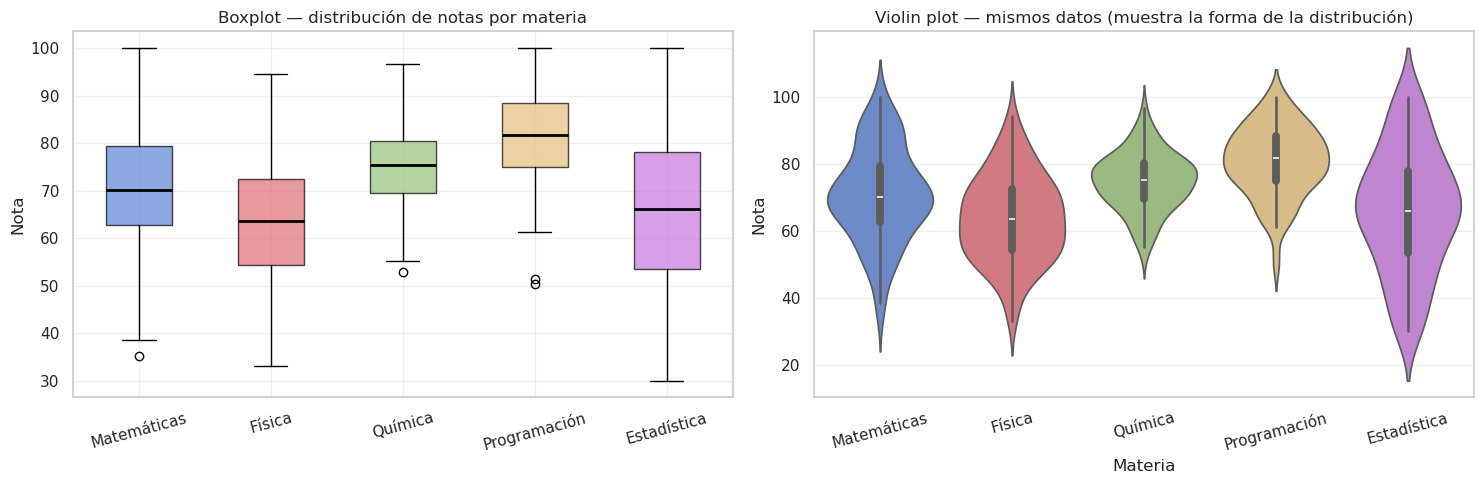

Dispersión (std) por materia:
  Matemáticas    : std = 14.0
  Física         : std = 12.9
  Química        : std = 8.6
  Programación   : std = 10.4
  Estadística    : std = 18.4


In [21]:
# Notas de 5 materias con diferentes características
materias_box = {
    'Matemáticas': rng.normal(70, 15, 100).clip(30, 100),
    'Física':      rng.normal(65, 12, 100).clip(30, 100),
    'Química':     rng.normal(75, 8,  100).clip(30, 100),
    'Programación':rng.normal(80, 10, 100).clip(30, 100),
    'Estadística': rng.normal(68, 18, 100).clip(30, 100),  # más dispersa
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ─── Panel izquierdo: Boxplot estándar ───
datos_lista = list(materias_box.values())
nombres     = list(materias_box.keys())

bp = axes[0].boxplot(datos_lista, patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})

# Colores para cada caja — ciclo for
colores_box = ['#5C85D6', '#E06C75', '#98C379', '#E5C07B', '#C678DD']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_xticklabels(nombres, rotation=15)
axes[0].set_title('Boxplot — distribución de notas por materia')
axes[0].set_ylabel('Nota')

# ─── Panel derecho: Violin plot (más detallado que boxplot) ───
df_notas_melt = pd.DataFrame(materias_box).melt(var_name='Materia', value_name='Nota')
sns.violinplot(data=df_notas_melt, x='Materia', y='Nota',
               palette=colores_box, ax=axes[1], inner='box')
axes[1].set_title('Violin plot — mismos datos (muestra la forma de la distribución)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

# Identificar la materia con mayor dispersión (mayor std)
print('Dispersión (std) por materia:')
for nombre, datos in materias_box.items():
    print(f'  {nombre:<15}: std = {datos.std():.1f}')

---
## 6. Heatmap — Mapa de Calor

### ¿Cuándo usar un heatmap?

El heatmap representa valores en una **matriz** usando color como tercera dimensión.
Es ideal para:
- **Matrices de correlación**: ver qué variables están relacionadas entre sí
- **Tablas de contingencia**: frecuencias cruzadas entre dos variables categóricas
- **Datos por dos dimensiones**: ventas por mes y producto, temperatura por hora y día

Los colores actúan como código: en el mapa `coolwarm`, el rojo intenso indica +1
(correlación perfecta positiva) y el azul intenso indica -1 (correlación perfecta negativa).

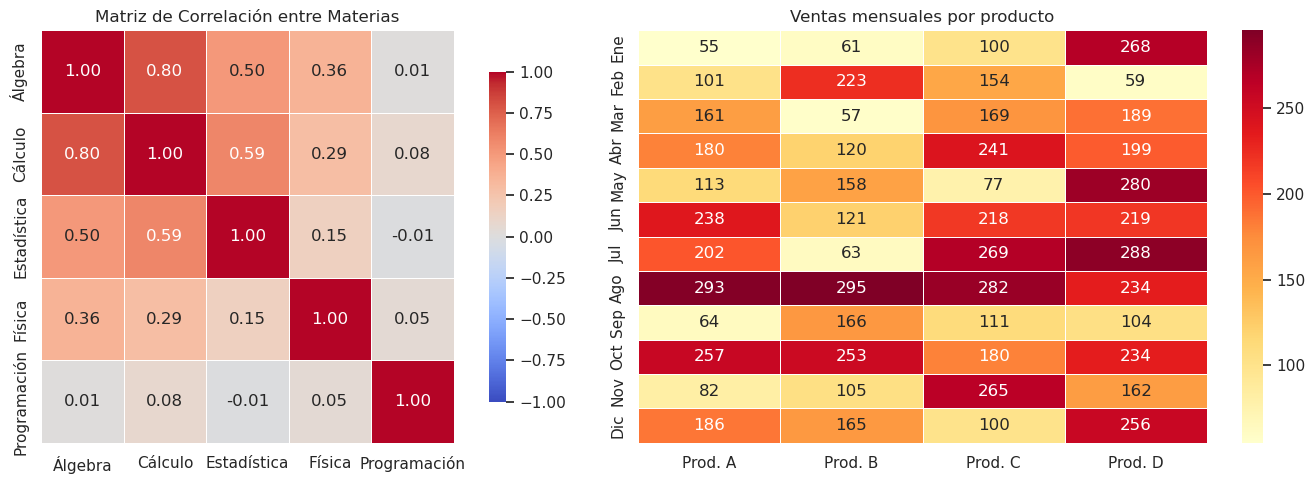

Par más correlacionado: Álgebra ↔ Cálculo  (r = 0.80)


In [22]:
# Generamos datos de materias con correlaciones artificiales
df_corr = pd.DataFrame(rng.normal(size=(150, 5)),
                        columns=['Álgebra', 'Cálculo', 'Estadística', 'Física', 'Programación'])

# Introducir correlaciones: Cálculo depende de Álgebra, Estadística depende de Cálculo
df_corr['Cálculo']     = df_corr['Álgebra']  * 0.8 + rng.normal(0, 0.6, 150)
df_corr['Estadística'] = df_corr['Cálculo']  * 0.6 + rng.normal(0, 0.8, 150)
df_corr['Física']      = df_corr['Álgebra']  * 0.5 + rng.normal(0, 0.9, 150)

corr = df_corr.corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ─── Panel izquierdo: Correlación completa ───
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=axes[0])
axes[0].set_title('Matriz de Correlación entre Materias')

# ─── Panel derecho: Heatmap de ventas (mes × producto) ───
productos = ['Prod. A', 'Prod. B', 'Prod. C', 'Prod. D']
meses_hm  = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
              'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
ventas    = rng.integers(50, 300, size=(12, 4))
df_ventas = pd.DataFrame(ventas, index=meses_hm, columns=productos)

sns.heatmap(df_ventas, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Ventas mensuales por producto')

plt.tight_layout()
plt.show()

# Identificar el par de materias más correlacionadas
# Usamos un ciclo for para recorrer la mitad inferior de la matriz
materias_list = corr.columns.tolist()
max_corr = 0
par_max  = ('', '')

for i in range(len(materias_list)):
    for j in range(i + 1, len(materias_list)):   # j siempre > i → evita duplicados
        valor = abs(corr.iloc[i, j])
        if valor > max_corr:
            max_corr = valor
            par_max  = (materias_list[i], materias_list[j])

print(f'Par más correlacionado: {par_max[0]} ↔ {par_max[1]}  (r = {max_corr:.2f})')

---
## 7. Subplots con Ciclo `for` — Paneles Automáticos

Una de las tareas más comunes es crear una cuadrícula de gráficas, una por variable.
Con un ciclo `for` podemos hacerlo sin repetir código, aunque tengamos 10 variables.

**Patrón típico:**
```python
fig, axes = plt.subplots(filas, columnas, figsize=(...))
axes = axes.flatten()   # convierte la matriz de axes en una lista

for i, variable in enumerate(lista_de_variables):
    axes[i].plot(...)   # graficar en el subplot i
    axes[i].set_title(variable)
```

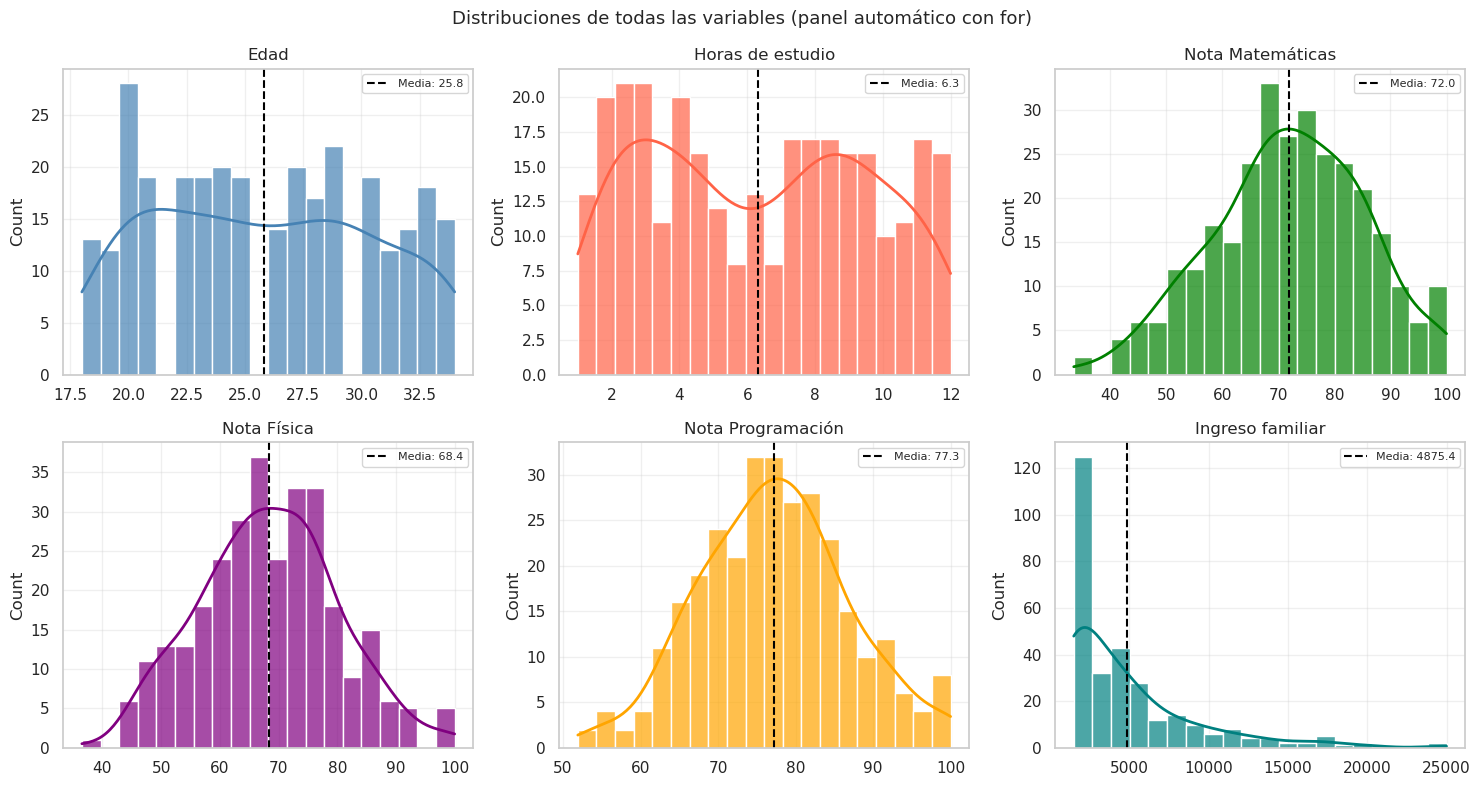

In [23]:
# Generamos un dataset de ejemplo con 6 variables
n_puntos = 300
df_panel = pd.DataFrame({
    'edad':       rng.integers(18, 35, n_puntos),
    'horas_est':  rng.uniform(1, 12, n_puntos).round(1),
    'nota_mat':   rng.normal(72, 14, n_puntos).clip(30, 100).round(1),
    'nota_fis':   rng.normal(68, 12, n_puntos).clip(30, 100).round(1),
    'nota_prog':  rng.normal(78, 10, n_puntos).clip(30, 100).round(1),
    'ingreso':    rng.exponential(5000, n_puntos).clip(1500, 25000).round(0),
})

# Lista de variables y sus configuraciones
variables = [
    ('edad',      'Edad',             'steelblue'),
    ('horas_est', 'Horas de estudio', 'tomato'),
    ('nota_mat',  'Nota Matemáticas', 'green'),
    ('nota_fis',  'Nota Física',      'purple'),
    ('nota_prog', 'Nota Programación','orange'),
    ('ingreso',   'Ingreso familiar', 'teal'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()    # ahora axes es una lista plana: axes[0], axes[1], ..., axes[5]

# === Ciclo for: un subplot por variable ===
for i, (col, titulo, color) in enumerate(variables):
    datos = df_panel[col].dropna()

    # Histograma con KDE
    sns.histplot(datos, bins=20, kde=True, ax=axes[i],
                 color=color, alpha=0.7,
                 line_kws={'linewidth': 2})

    media = datos.mean()
    axes[i].axvline(media, color='black', linestyle='--',
                    linewidth=1.5, label=f'Media: {media:.1f}')
    axes[i].set_title(titulo)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

fig.suptitle('Distribuciones de todas las variables (panel automático con for)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Personalización Avanzada

Matplotlib permite controlar casi cualquier aspecto visual de una figura.
Algunos ajustes útiles:

| Elemento | Código |
|---|---|
| Título de la figura | `ax.set_title('...')` |
| Etiquetas de ejes | `ax.set_xlabel('...')`, `ax.set_ylabel('...')` |
| Límites de ejes | `ax.set_xlim(a, b)`, `ax.set_ylim(a, b)` |
| Marcas del eje | `ax.set_xticks([...])`, `ax.set_xticklabels([...])` |
| Anotación con flecha | `ax.annotate('texto', xy=(x,y), xytext=(x2,y2), arrowprops={...})` |
| Quitar bordes | `ax.spines['top'].set_visible(False)` |
| Leyenda | `ax.legend(loc='upper right', title='...')` |

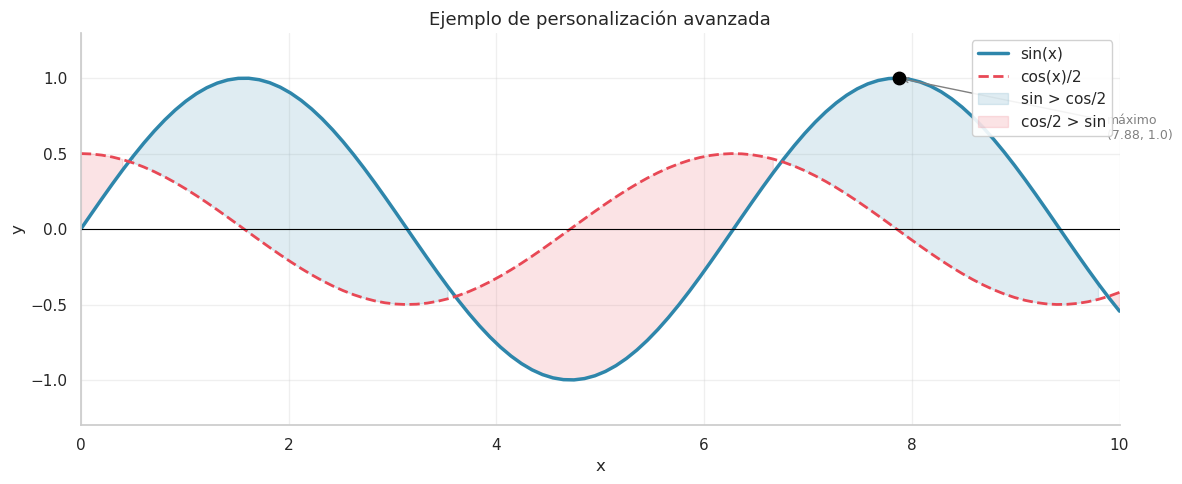

In [24]:
x  = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x) * 0.5

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, y1, color='#2E86AB', linewidth=2.5, linestyle='-',  label='sin(x)')
ax.plot(x, y2, color='#E84855', linewidth=2.0, linestyle='--', label='cos(x)/2')

# Zonas sombreadas según condición
ax.fill_between(x, y1, y2, where=(y1 > y2), alpha=0.15, color='#2E86AB', label='sin > cos/2')
ax.fill_between(x, y1, y2, where=(y1 < y2), alpha=0.15, color='#E84855', label='cos/2 > sin')

# Anotar el máximo de sin(x)
idx_max = np.argmax(y1)            # índice del máximo
xp, yp  = x[idx_max], y1[idx_max]
ax.annotate(f'máximo\n({xp:.2f}, {yp:.1f})',
            xy=(xp, yp),           # punta de la flecha
            xytext=(xp + 2, yp - 0.4),  # texto de la anotación
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')
ax.scatter([xp], [yp], s=80, color='black', zorder=5)

# Quitar bordes superior y derecho (estilo minimalista)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(0, 10)
ax.set_ylim(-1.3, 1.3)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Ejemplo de personalización avanzada', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

---
## 9. Gráficas Estadísticas con Seaborn

Seaborn brilla cuando tienes un **DataFrame** y quieres gráficas estadísticas con poco código.
Su ventaja principal: el parámetro `hue` añade automáticamente colores por categoría.

Gráficas más usadas en Seaborn:
- `sns.histplot` — histograma mejorado con KDE opcional
- `sns.boxplot` / `sns.violinplot` — distribuciones por grupo
- `sns.scatterplot` — scatter con colores/formas por categoría
- `sns.barplot` — barras con intervalo de confianza automático
- `sns.heatmap` — heatmap con anotaciones
- `sns.pairplot` — relaciones entre todas las variables numéricas

/tmp/ipykernel_216828/4007730168.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_seaborn, x='carrera', y='nota',


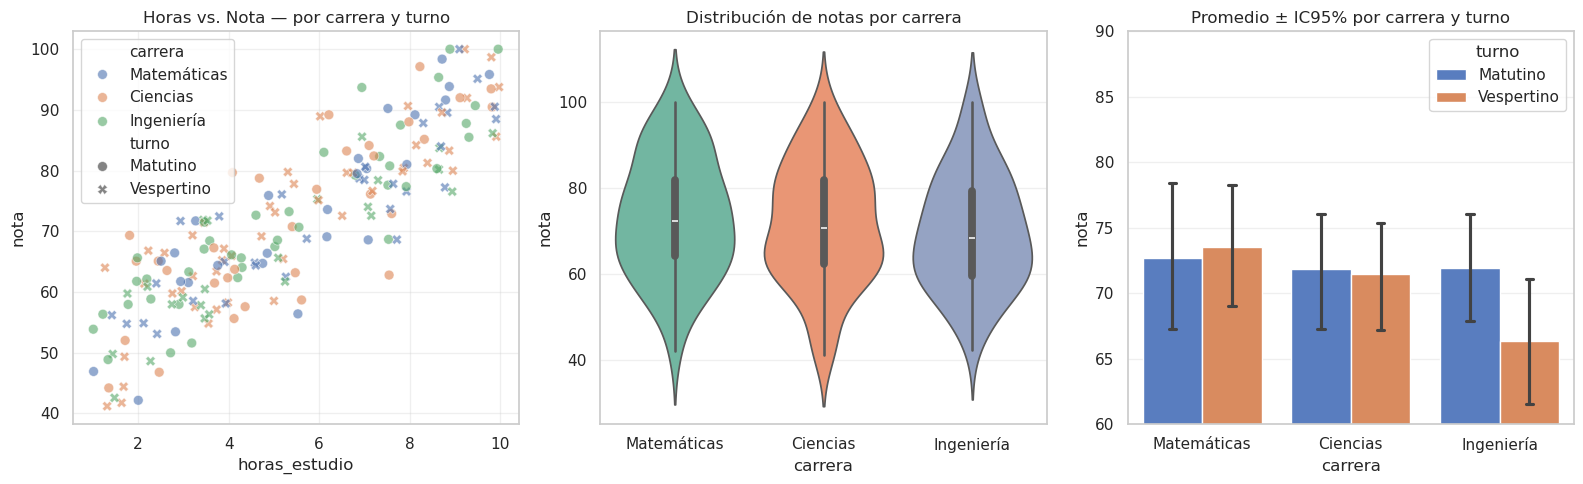

In [25]:
# Construir dataset
n_s = 200
df_seaborn = pd.DataFrame({
    'horas_estudio': rng.uniform(1, 10, n_s),
    'carrera':       rng.choice(['Ingeniería', 'Ciencias', 'Matemáticas'], n_s),
    'turno':         rng.choice(['Matutino', 'Vespertino'], n_s),
})
df_seaborn['nota'] = (48 + 4.5 * df_seaborn['horas_estudio'] + rng.normal(0, 7, n_s)).clip(30, 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# scatterplot con hue (color) y style (forma de los puntos)
sns.scatterplot(data=df_seaborn, x='horas_estudio', y='nota',
                hue='carrera', style='turno',
                alpha=0.6, s=50, ax=axes[0])
axes[0].set_title('Horas vs. Nota — por carrera y turno')

# violinplot: muestra la distribución completa, no solo los cuartiles
orden_carreras = (df_seaborn.groupby('carrera')['nota']
                  .median().sort_values(ascending=False).index)
sns.violinplot(data=df_seaborn, x='carrera', y='nota',
               order=orden_carreras, palette='Set2',
               inner='box', ax=axes[1])
axes[1].set_title('Distribución de notas por carrera')

# barplot: promedio con intervalo de confianza del 95%
sns.barplot(data=df_seaborn, x='carrera', y='nota',
            hue='turno', palette='muted',
            order=orden_carreras,
            errorbar='ci', capsize=0.1, ax=axes[2])
axes[2].set_title('Promedio ± IC95% por carrera y turno')
axes[2].set_ylim(60, 90)

plt.tight_layout()
plt.show()

---
## Ejercicio 1 — Dashboard de Temperaturas

### Enunciado

Se tienen datos de temperatura mensual para 4 ciudades durante 2 años.
Tu tarea es crear un **dashboard de 4 paneles** que muestre:

1. **Panel superior** (ancho completo): líneas de temperatura para cada ciudad — usa un ciclo `for`
2. **Panel inferior izquierdo**: histograma de temperaturas para cada ciudad superpuesto
3. **Panel inferior centro**: boxplot comparando las 4 ciudades
4. **Panel inferior derecho**: barras con el promedio anual de cada ciudad, **coloreadas en rojo**
   si el promedio < 20°C y en **azul** si ≥ 20°C

**Datos disponibles:**
```python
meses = list(range(1, 13))  # 1 a 12
datos_ciudades = {
    'Ciudad A': [18, 19, 21, 24, 26, 27, 27, 26, 25, 23, 20, 18],
    'Ciudad B': [12, 13, 15, 17, 18, 17, 16, 16, 16, 15, 13, 12],
    'Ciudad C': [25, 26, 27, 28, 29, 29, 29, 29, 28, 27, 26, 25],
    'Ciudad D': [22, 23, 24, 25, 26, 27, 27, 26, 25, 24, 23, 22],
}
```

**Pistas:**
- Usa `GridSpec` para lograr el layout (1 panel arriba, 3 abajo)
- Itera sobre `datos_ciudades.items()` para los paneles 1 y 2
- Para el boxplot, usa `list(datos_ciudades.values())`

In [26]:
# === Intenta tu solución aquí ===
# Puedes usar la celda siguiente para ver la solución completa


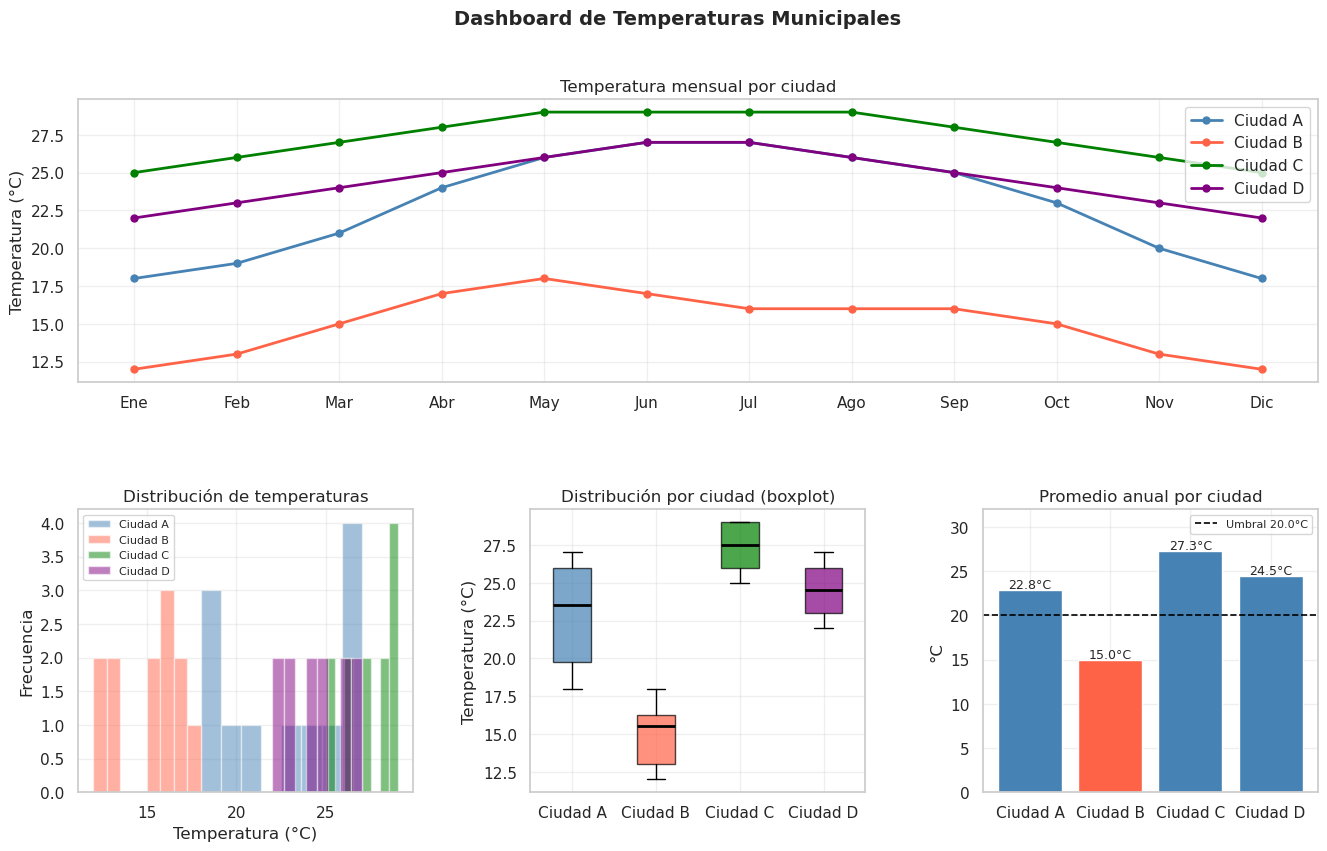

In [27]:
# ═══════════════════════════════════════════════════════
#  SOLUCIÓN — Ejercicio 1: Dashboard de Temperaturas
# ═══════════════════════════════════════════════════════
from matplotlib.gridspec import GridSpec

meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
x_meses       = range(12)

datos_ciudades = {
    'Ciudad A': [18, 19, 21, 24, 26, 27, 27, 26, 25, 23, 20, 18],
    'Ciudad B': [12, 13, 15, 17, 18, 17, 16, 16, 16, 15, 13, 12],
    'Ciudad C': [25, 26, 27, 28, 29, 29, 29, 29, 28, 27, 26, 25],
    'Ciudad D': [22, 23, 24, 25, 26, 27, 27, 26, 25, 24, 23, 22],
}
colores_ciudades = ['steelblue', 'tomato', 'green', 'purple']

# ── Layout: 1 fila arriba + 3 columnas abajo ──
fig = plt.figure(figsize=(16, 9))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax_linea = fig.add_subplot(gs[0, :])      # fila 0, todas las columnas
ax_hist  = fig.add_subplot(gs[1, 0])      # fila 1, col 0
ax_box   = fig.add_subplot(gs[1, 1])      # fila 1, col 1
ax_bar   = fig.add_subplot(gs[1, 2])      # fila 1, col 2

# ─────────────────────────────────────────────
# Panel 1: Líneas — ciclo for sobre el diccionario
# ─────────────────────────────────────────────
for (ciudad, temps), color in zip(datos_ciudades.items(), colores_ciudades):
    ax_linea.plot(x_meses, temps, marker='o', linewidth=2,
                  markersize=5, label=ciudad, color=color)

ax_linea.set_xticks(x_meses)
ax_linea.set_xticklabels(meses_nombres)
ax_linea.set_title('Temperatura mensual por ciudad')
ax_linea.set_ylabel('Temperatura (°C)')
ax_linea.legend(loc='upper right')

# ─────────────────────────────────────────────
# Panel 2: Histogramas superpuestos
# ─────────────────────────────────────────────
for (ciudad, temps), color in zip(datos_ciudades.items(), colores_ciudades):
    ax_hist.hist(temps, bins=8, alpha=0.5, color=color, label=ciudad, edgecolor='white')

ax_hist.set_title('Distribución de temperaturas')
ax_hist.set_xlabel('Temperatura (°C)')
ax_hist.set_ylabel('Frecuencia')
ax_hist.legend(fontsize=8)

# ─────────────────────────────────────────────
# Panel 3: Boxplot
# ─────────────────────────────────────────────
nombres_ciudades = list(datos_ciudades.keys())
datos_lista_box  = list(datos_ciudades.values())

bp = ax_box.boxplot(datos_lista_box, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colores_ciudades):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax_box.set_xticklabels(nombres_ciudades)
ax_box.set_title('Distribución por ciudad (boxplot)')
ax_box.set_ylabel('Temperatura (°C)')

# ─────────────────────────────────────────────
# Panel 4: Barras con color condicional
# ─────────────────────────────────────────────
UMBRAL = 20.0
promedios_anuales = []
colores_barra     = []

for ciudad, temps in datos_ciudades.items():
    promedio = sum(temps) / len(temps)   # promedio anual
    promedios_anuales.append(promedio)
    # Condicional: color según si supera el umbral
    if promedio >= UMBRAL:
        colores_barra.append('steelblue')
    else:
        colores_barra.append('tomato')

bars = ax_bar.bar(nombres_ciudades, promedios_anuales,
                  color=colores_barra, edgecolor='white')

# Etiquetas sobre las barras
for bar in bars:
    ax_bar.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                f'{bar.get_height():.1f}°C',
                ha='center', fontsize=9)

ax_bar.axhline(UMBRAL, color='black', linestyle='--', linewidth=1.2,
               label=f'Umbral {UMBRAL}°C')
ax_bar.set_title('Promedio anual por ciudad')
ax_bar.set_ylabel('°C')
ax_bar.set_ylim(0, 32)
ax_bar.legend(fontsize=8)

fig.suptitle('Dashboard de Temperaturas Municipales', fontsize=14, fontweight='bold')
plt.show()

---
## Ejercicio 2 — Reporte Visual de Notas por Materia

### Enunciado

Tienes las notas de 5 estudiantes en 4 materias:

```python
estudiantes = ['Ana', 'Bruno', 'Carla', 'Diego', 'Elena']
notas_por_materia = {
    'Matemáticas': [85, 62, 90, 55, 78],
    'Física':      [70, 58, 85, 48, 72],
    'Química':     [78, 65, 88, 60, 80],
    'Programación':[92, 75, 95, 70, 88],
}
```

Crea una figura con 2 paneles lado a lado:

**Panel izquierdo** — Gráfica de líneas:
- Una línea por estudiante mostrando sus notas en las 4 materias (eje X)
- Usa un ciclo `for` para iterar sobre los estudiantes
- Agrega marcadores en cada punto

**Panel derecho** — Barras del promedio por materia:
- Una barra por materia con el promedio del grupo
- Color **verde** si el promedio ≥ 75, **amarillo** si entre 65 y 74, **rojo** si < 65
- Agrega el valor numérico sobre cada barra

**Extra:** Imprime (en texto) cuál es el estudiante con mayor promedio general.

In [28]:
# === Intenta tu solución aquí ===


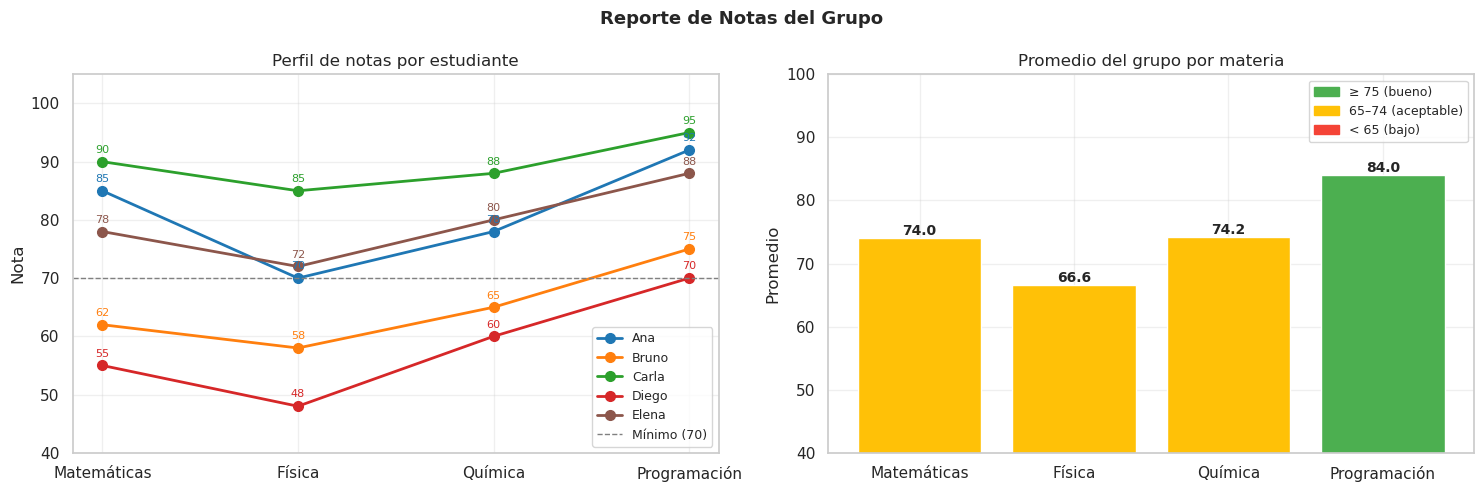

Estudiante con mejor promedio general: Carla (89.5)


In [29]:
# ═══════════════════════════════════════════════════════
#  SOLUCIÓN — Ejercicio 2: Reporte Visual de Notas
# ═══════════════════════════════════════════════════════

estudiantes = ['Ana', 'Bruno', 'Carla', 'Diego', 'Elena']
notas_por_materia = {
    'Matemáticas': [85, 62, 90, 55, 78],
    'Física':      [70, 58, 85, 48, 72],
    'Química':     [78, 65, 88, 60, 80],
    'Programación':[92, 75, 95, 70, 88],
}
materias_ord = list(notas_por_materia.keys())
x_materias   = range(len(materias_ord))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ─────────────────────────────────────────────
# Panel izquierdo: perfil de notas por estudiante
# ─────────────────────────────────────────────
colores_est = plt.cm.tab10(np.linspace(0, 0.5, len(estudiantes)))

for i, estudiante in enumerate(estudiantes):
    # Recolectar la nota de este estudiante en cada materia
    notas_est = [notas_por_materia[mat][i] for mat in materias_ord]

    axes[0].plot(x_materias, notas_est,
                 marker='o', linewidth=2, markersize=7,
                 color=colores_est[i],
                 label=estudiante)

    # Anotar la nota en cada punto
    for j, nota in enumerate(notas_est):
        axes[0].text(j, nota + 1.5, str(nota),
                     ha='center', fontsize=8, color=colores_est[i])

axes[0].axhline(70, color='gray', linestyle='--', linewidth=1, label='Mínimo (70)')
axes[0].set_xticks(x_materias)
axes[0].set_xticklabels(materias_ord)
axes[0].set_ylim(40, 105)
axes[0].set_title('Perfil de notas por estudiante')
axes[0].set_ylabel('Nota')
axes[0].legend(fontsize=9)

# ─────────────────────────────────────────────
# Panel derecho: promedio por materia con color condicional
# ─────────────────────────────────────────────
promedios_materia = []
colores_prom      = []

for materia in materias_ord:
    notas_m  = notas_por_materia[materia]
    promedio = sum(notas_m) / len(notas_m)
    promedios_materia.append(promedio)

    # Condicional: tres niveles de color
    if promedio >= 75:
        colores_prom.append('#4CAF50')   # verde → buen rendimiento
    elif promedio >= 65:
        colores_prom.append('#FFC107')   # amarillo → aceptable
    else:
        colores_prom.append('#F44336')   # rojo → bajo rendimiento

bars = axes[1].bar(materias_ord, promedios_materia,
                   color=colores_prom, edgecolor='white')

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Promedio del grupo por materia')
axes[1].set_ylabel('Promedio')
axes[1].set_ylim(40, 100)

# Leyenda de colores manual
from matplotlib.patches import Patch
leyenda_colores = [
    Patch(color='#4CAF50', label='≥ 75 (bueno)'),
    Patch(color='#FFC107', label='65–74 (aceptable)'),
    Patch(color='#F44336', label='< 65 (bajo)'),
]
axes[1].legend(handles=leyenda_colores, fontsize=9)

fig.suptitle('Reporte de Notas del Grupo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Encontrar al estudiante con mayor promedio general ───
mejor_promedio = 0
mejor_estudiante = ''

for i, est in enumerate(estudiantes):
    # Recolectar todas las notas de este estudiante
    notas_est = [notas_por_materia[mat][i] for mat in materias_ord]
    prom_est  = sum(notas_est) / len(notas_est)

    if prom_est > mejor_promedio:
        mejor_promedio   = prom_est
        mejor_estudiante = est

print(f'Estudiante con mejor promedio general: {mejor_estudiante} ({mejor_promedio:.1f})')